# 🤖 Modelagem Preditiva de NPS — Regressão

**Objetivo:** Prever o `nps_score` (variável contínua de 0 a 10) usando apenas dados operacionais disponíveis **antes** da coleta do NPS.

**Fluxo:**
1. Importações
2. Carregamento
3. Tratamento de data leakage
4. Preparação dos dados
5. Treinamento de múltiplos modelos
6. Avaliação e comparação
7. Análise do melhor modelo

---
## 1. Importações

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV


import warnings
warnings.filterwarnings('ignore')

SEED = 42
print('Libs carregadas ✅')

Libs carregadas ✅


---
## 2. Carregamento

In [218]:
df = pd.read_csv('../data/desafio_nps_fase_1.csv')

print(f'Shape: {df.shape}')
df.head()

Shape: (2500, 19)


,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9


---
## 3. Tratamento de Data Leakage

**Data leakage** acontece quando usamos como feature informações que, na prática, só estariam disponíveis **depois** da coleta do NPS — ou que derivam diretamente dele.

| Coluna | Motivo da remoção |
|---|---|
| `csat_internal_score` | Nota de satisfação interna coletada junto ou após o NPS — proxy direto do target |
| `repeat_purchase_30d` | Recompra nos 30 dias posteriores ao pedido — evento futuro |


In [219]:
# Colunas removidas por leakage e por serem apenas identificadores

LEAKAGE_COLS = [
    'csat_internal_score',  # coletado junto/após o NPS
    'repeat_purchase_30d'
]

ID_COLS = ['customer_id', 'order_id']

df_model = df.drop(columns=LEAKAGE_COLS + ID_COLS)
df_model.head()

,customer_age,customer_region,customer_tenure_months,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,complaints_count
0,63,Nordeste,14,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,3
1,20,Sul,1,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,3
2,46,Nordeste,111,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,7
3,52,Centro-Oeste,117,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,4
4,56,Norte,50,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,3


---
## 4. Preparação dos Dados

In [ ]:
#  Verificação de nulos
df_model.info()

<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_age               2500 non-null   int64  
 1   customer_region            2500 non-null   str    
 2   customer_tenure_months     2500 non-null   int64  
 3   order_value                2500 non-null   float64
 4   items_quantity             2500 non-null   int64  
 5   discount_value             2500 non-null   float64
 6   payment_installments       2500 non-null   int64  
 7   delivery_time_days         2500 non-null   int64  
 8   delivery_delay_days        2500 non-null   int64  
 9   freight_value              2500 non-null   float64
 10  delivery_attempts          2500 non-null   int64  
 11  customer_service_contacts  2500 non-null   int64  
 12  resolution_time_days       2500 non-null   int64  
 13  nps_score                  2500 non-null   float64
 14  com

In [221]:
# Encoding de variável categórica
# customer_region é string; convertemos para inteiro.

le = LabelEncoder()
df_model['customer_region'] = le.fit_transform(df_model['customer_region'])

for i, r in enumerate(le.classes_):
    print(f'  {i} → {r}')

  0 → Centro-Oeste
  1 → Nordeste
  2 → Norte
  3 → Sudeste
  4 → Sul


In [222]:
# Separação X / y 
# Target: nps_score (regressão contínua, 0–10)

X = df_model.drop(columns=['nps_score'])
y = df_model['nps_score']

In [223]:
#  Split treino / teste 
# 80% treino, 20% teste.

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

print(f'Treino: {len(X_train)} | Teste: {len(X_test)}')

Treino: 2000 | Teste: 500


In [224]:
# Normalização 
# StandardScaler para modelos sensíveis à escala (Linear, Ridge, KNN).
# Fit SOMENTE no treino — evita vazamento de informação do teste.

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print('Normalização aplicada')

Normalização aplicada


---
## 5. Treinamento dos Modelos

Modelos lineares recebem dados normalizados; árvores recebem dados originais.

In [ ]:
# Definição dos modelos 


models = {
    'Linear Regression': (
        LinearRegression(),
        X_train_sc, X_test_sc
    ),

    'Ridge Regression': (
        GridSearchCV(
            Ridge(),
            param_grid={'alpha': [0.01, 0.1, 1, 10, 100]},
            cv=5,
            scoring='r2',
            n_jobs=-1
        ),
        X_train_sc, X_test_sc
    ),

    'KNN': (
        GridSearchCV(
            KNeighborsRegressor(),
            param_grid={
                'n_neighbors': [3, 5, 7, 9],
                'weights': ['uniform', 'distance']
            },
            cv=5,
            scoring='r2',
            n_jobs=-1
        ),
        X_train_sc, X_test_sc
    ),

    'Decision Tree': (
        GridSearchCV(
            DecisionTreeRegressor(random_state=SEED),
            param_grid={
                'max_depth': [3, 5, 7, 10, None],
                'min_samples_split': [2, 5, 10]
            },
            cv=5,
            scoring='r2',
            n_jobs=-1
        ),
        X_train, X_test
    ),

    'Random Forest': (
        GridSearchCV(
            RandomForestRegressor(random_state=SEED),
            param_grid={
                'n_estimators': [50, 100, 200],
                'max_depth': [5, 10, None]
            },
            cv=5,
            scoring='r2',
            n_jobs=-1
        ),
        X_train, X_test
    ),

    'Gradient Boosting': (
        GridSearchCV(
            GradientBoostingRegressor(random_state=SEED),
            param_grid={
                'n_estimators': [50, 100, 200],
                'learning_rate': [0.01, 0.05, 0.1],
                'max_depth': [3, 5]
            },
            cv=5,
            scoring='r2',
            n_jobs=-1
        ),
        X_train, X_test
    ),
}

In [226]:
# Treino e avaliação 
# Métricas: MAE (erro médio absoluto), RMSE e R².

results = []

for name, (model, X_tr, X_te) in models.items():
    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)

    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)

    results.append({'Modelo': name, 'MAE': round(mae, 4), 'RMSE': round(rmse, 4), 'R²': round(r2, 4)})

df_results = pd.DataFrame(results).sort_values('R²', ascending=False).reset_index(drop=True)



---
## 6. Comparação dos Resultados

In [227]:
# Tabela estilizada 
# Verde = melhor R² | Vermelho = maior erro

df_results

,Modelo,MAE,RMSE,R²
0,Ridge Regression,1.3343,1.6873,0.5494
1,Linear Regression,1.3347,1.6876,0.5493
2,Gradient Boosting,1.3607,1.6914,0.5473
3,Random Forest,1.4225,1.7639,0.5076
4,Decision Tree,1.4889,1.8564,0.4546
5,KNN,1.5755,1.9531,0.3963


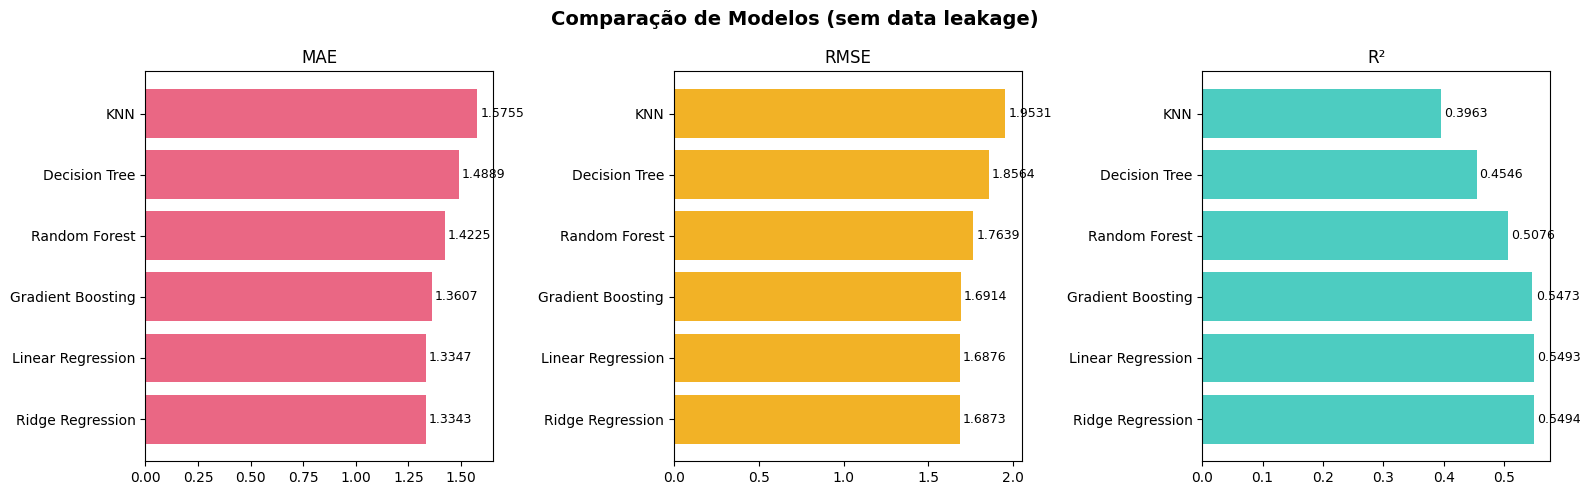

In [ ]:
#  Gráfico comparativo

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Comparação de Modelos', fontsize=14, fontweight='bold')

metrics_cfg = [('MAE', '#e74c6f', True), ('RMSE', '#f0a500', True), ('R²', '#2ec4b6', False)]

for ax, (metric, color, asc) in zip(axes, metrics_cfg):
    df_plot = df_results.sort_values(metric, ascending=asc)
    ax.barh(df_plot['Modelo'], df_plot[metric], color=color, alpha=0.85)
    ax.set_title(metric, fontsize=12)
    for i, v in enumerate(df_plot[metric]):
        ax.text(v * 1.01, i, f'{v:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

---
## 7. Análise do Melhor Modelo

In [ ]:
# Seleção automática por R² 

best_name = df_results.iloc[0]['Modelo']
best_model, X_tr_best, X_te_best = models[best_name]

# salva modelo
joblib.dump(best_model, '../models/model.pkl')

# previsão teste
y_pred_best = best_model.predict(X_te_best)

print(f'🏆 Melhor modelo: {best_name}')
print(f'R²   = {r2_score(y_test, y_pred_best):.4f}')
print(f'MAE  = {mean_absolute_error(y_test, y_pred_best):.4f}')
print(f'RMSE = {np.sqrt(mean_squared_error(y_test, y_pred_best)):.4f}')
print('Modelo salvo em: model.pkl')

🏆 Melhor modelo: Ridge Regression
R²   = 0.5494
MAE  = 1.3343
RMSE = 1.6873
Modelo salvo em: best_model.pkl


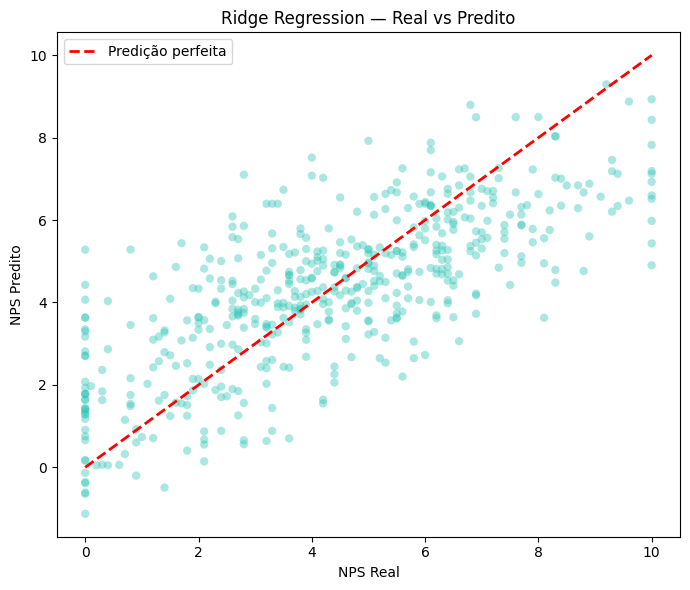

In [230]:
# Real vs Predito
# Pontos próximos da linha = boas predições.

plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred_best, alpha=0.4, color='#2ec4b6', edgecolors='none')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Predição perfeita')
plt.xlabel('NPS Real')
plt.ylabel('NPS Predito')
plt.title(f'{best_name} — Real vs Predito')
plt.legend()
plt.tight_layout()
plt.show()

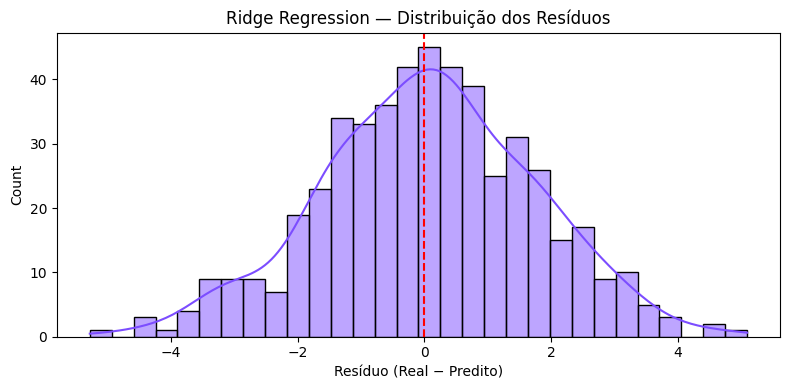

Média dos resíduos: 0.0505  (ideal: próximo de 0)


In [231]:
# Distribuição dos resíduos 
# Resíduos centrados em 0 indicam ausência de viés sistemático.

residuals = y_test - y_pred_best

plt.figure(figsize=(8, 4))
sns.histplot(residuals, bins=30, kde=True, color='#7c4dff')
plt.axvline(0, color='red', linestyle='--', linewidth=1.5)
plt.xlabel('Resíduo (Real − Predito)')
plt.title(f'{best_name} — Distribuição dos Resíduos')
plt.tight_layout()
plt.show()

print(f'Média dos resíduos: {residuals.mean():.4f}  (ideal: próximo de 0)')

In [232]:
# Importância das features
# Disponível para modelos de árvore (Random Forest, Gradient Boosting, Decision Tree).

if hasattr(best_model, 'best_estimator_'):
    model_to_plot = best_model.best_estimator_
else:
    model_to_plot = best_model

if hasattr(model_to_plot, 'feature_importances_'):
    importances = pd.Series(
        model_to_plot.feature_importances_,
        index=X.columns
    ).sort_values(ascending=True)

    plt.figure(figsize=(8, 5))
    importances.plot(kind='barh')
    plt.title(f'{best_name} — Importância das Features')
    plt.xlabel('Importância Relativa')
    plt.tight_layout()
    plt.show()
else:
    print(f'{best_name} não possui feature_importances_.')

Ridge Regression não possui feature_importances_.


---
# 8 teste modelo

In [ ]:
X_test_sc_df = pd.DataFrame(
    X_test_sc,
    index=X_test.index,
    columns=X_test.columns
)

modelo = joblib.load('../models/model.pkl')


def classificar_nps(nota):
    if nota <= 6:
        return 'Detrator'
    elif nota <= 8:
        return 'Neutro'
    return 'Promotor'


# base escalada convertida para DataFrame
X_test_sc_df = pd.DataFrame(
    X_test_sc,
    index=X_test.index,
    columns=X_test.columns
)

detrator = X_test_sc_df[y_test <= 6].sample(1)
neutro   = X_test_sc_df[(y_test >= 7) & (y_test <= 8)].sample(1)
promotor = X_test_sc_df[y_test >= 9].sample(1)

casos_teste = pd.concat([detrator, neutro, promotor])

pred = modelo.predict(casos_teste).clip(0, 10)

resultado = pd.DataFrame({
    'NPS Real': y_test.loc[casos_teste.index].values.round(1),
    'NPS Predito': pred.round(1)
})

resultado['Categoria Real'] = [
    classificar_nps(v) for v in resultado['NPS Real']
]

resultado['Categoria Predita'] = [
    classificar_nps(v) for v in resultado['NPS Predito']
]

resultado['Acertou Categoria'] = (
    resultado['Categoria Real'] == resultado['Categoria Predita']
)

resultado.index = ['Detrator', 'Neutro', 'Promotor']

display(resultado)

,NPS Real,NPS Predito,Categoria Real,Categoria Predita,Acertou Categoria
Detrator,5.6,4.7,Detrator,Detrator,True
Neutro,7.1,6.7,Neutro,Neutro,True
Promotor,10.0,8.4,Promotor,Promotor,True


---
## 9. Conclusão

In [234]:
# Resumo final 

print('=' * 55)
print('RESUMO — REGRESSÃO NPS')
print('=' * 55)
print(df_results.to_string(index=False))
print('=' * 55)
print(f'\n🏆 Modelo escolhido: {best_name}')
print()
print('Variáveis removidas por leakage:')

RESUMO — REGRESSÃO NPS
           Modelo    MAE   RMSE     R²
 Ridge Regression 1.3343 1.6873 0.5494
Linear Regression 1.3347 1.6876 0.5493
Gradient Boosting 1.3607 1.6914 0.5473
    Random Forest 1.4225 1.7639 0.5076
    Decision Tree 1.4889 1.8564 0.4546
              KNN 1.5755 1.9531 0.3963

🏆 Modelo escolhido: Ridge Regression

Variáveis removidas por leakage:
